# **LAB 4: PyTorch Linear Regression**

## **OBJECTIVE**
To understand the basics of building, training, and evaluating a Linear Regression model using PyTorch. This includes data preparation, model creation using `nn.Module`, defining loss functions and optimizers, and implementing a training loop.

## **THEORY**

### Linear Regression in PyTorch
Linear regression is a fundamental algorithm in machine learning that models the relationship between a dependent variable and one or more independent variables. In PyTorch, we can implement this by creating a custom model class that inherits from `nn.Module`.

### Training a Model
The training process involves:
1. **Forward Pass:** Passing the input data through the model to get predictions.
2. **Calculating Loss:** Measuring how far off the predictions are from the actual true values using a loss function (e.g., L1Loss or MSELoss).
3. **Zeroing Gradients:** Clearing old gradients from the previous step.
4. **Backward Pass (Backpropagation):** Computing the gradient of the loss with respect to the model parameters.
5. **Optimizer Step:** Updating the model parameters using an optimizer (e.g., SGD).

In [5]:
import torch
import matplotlib.pyplot as plt
from torch import nn
import pandas as pd

print("PyTorch Version:", torch.__version__)

PyTorch Version: 2.12.0+cu132


In [6]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [7]:
# Load the assignment data
df = pd.read_csv('assignment-data2.csv')
df.head()

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00


In [8]:
# Convert to torch tensors
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)

# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

print(f"Training data: {len(X_train)} samples")
print(f"Testing data: {len(X_test)} samples")

Training data: 79 samples
Testing data: 20 samples


In [ ]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
    plt.title("Ritik Thakur")
    plt.legend(prop={"size": 14})


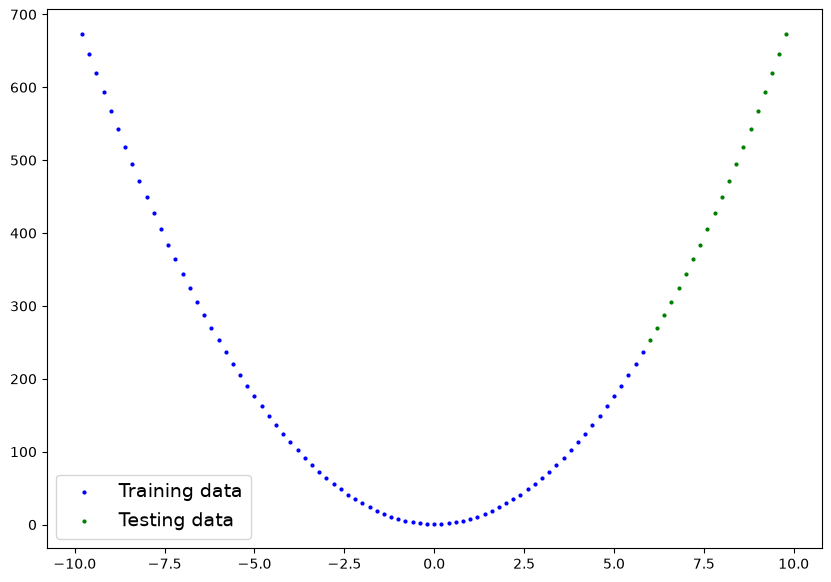

In [10]:
plot_predictions()

In [11]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__() 
        self.weights = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

In [12]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [13]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [14]:
torch.manual_seed(42)
epochs = 200

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    model_0.train()
    y_pred = model_0(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_pred = model_0(X_test)
        test_loss = loss_fn(test_pred, y_test.type(torch.float))

        if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss:.4f} | MAE Test Loss: {test_loss:.4f}")

Epoch: 0 | MAE Train Loss: 175.1446 | MAE Test Loss: 444.5394
Epoch: 10 | MAE Train Loss: 174.6446 | MAE Test Loss: 446.0193
Epoch: 20 | MAE Train Loss: 174.1446 | MAE Test Loss: 447.4993
Epoch: 30 | MAE Train Loss: 173.6446 | MAE Test Loss: 448.9793
Epoch: 40 | MAE Train Loss: 173.1446 | MAE Test Loss: 450.4593
Epoch: 50 | MAE Train Loss: 172.6446 | MAE Test Loss: 451.9394
Epoch: 60 | MAE Train Loss: 172.1446 | MAE Test Loss: 453.4193
Epoch: 70 | MAE Train Loss: 171.6446 | MAE Test Loss: 454.8993
Epoch: 80 | MAE Train Loss: 171.1446 | MAE Test Loss: 456.3793
Epoch: 90 | MAE Train Loss: 170.6475 | MAE Test Loss: 457.8597
Epoch: 100 | MAE Train Loss: 170.1594 | MAE Test Loss: 459.3408
Epoch: 110 | MAE Train Loss: 169.6713 | MAE Test Loss: 460.8217
Epoch: 120 | MAE Train Loss: 169.1836 | MAE Test Loss: 462.3023
Epoch: 130 | MAE Train Loss: 168.7043 | MAE Test Loss: 463.7779
Epoch: 140 | MAE Train Loss: 168.2250 | MAE Test Loss: 465.2535
Epoch: 150 | MAE Train Loss: 167.7457 | MAE Test Lo

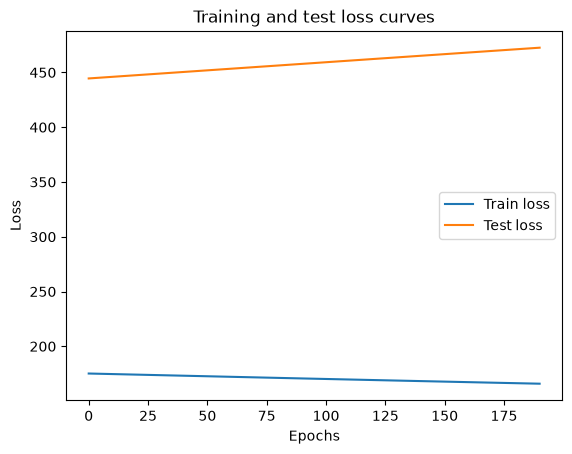

In [15]:
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

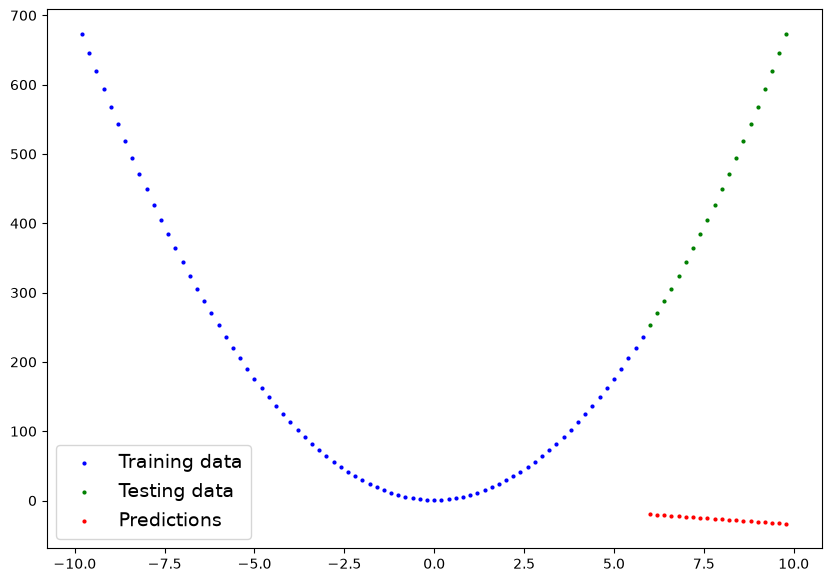

In [16]:
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

## **DISCUSSION**
In this lab exercise, we built a Linear Regression model in PyTorch and trained it on `assignment-data2.csv`. We followed the standard training workflow: forward pass, loss computation, backpropagation, and optimization steps.

A key observation is that the dataset shows a non-linear, parabolic relationship. Since we used a simple linear model ($y = mx + b$), the model can only learn a straight-line approximation and cannot fully capture the quadratic pattern in the data. This leads to underfitting.

For non-linear data, a more expressive model is needed, such as polynomial regression or a neural network with hidden layers and non-linear activation functions.

## **CONCLUSIONS**
This lab successfully achieved the goal of creating and training a PyTorch model from scratch. We learned how to define a custom model using `nn.Module`, how to add a loss function and how to use gradient descent with an optimizer to train the parameters over multiple epochs. The linear model wasn't the best fit for this particular non-linear dataset, but the PyTorch training loop and the concepts behind it are the same and provide a solid foundation for building more advanced deep learning models.